# TME 5 : Exploration/Interprétation de Résultats

Nom Etudiant 1: <font color='blue'>ZAMORE Kenjy</font>
<br>
Nom Etudiant 2: <font color='blue'>NOM Prénom</font>

## Partie A : Analyse de données peaks
Nous allons revenir à nos données afin de réaliser une analyse descriptive. Ouvrir et lire les séquences de votre fichier et répondre aux questions suivante :

1\. Il y a combien de séquences? Quel est le pourcentage de nucléotides (A, C, G, T)? Quel est la taille moyenne de ces séquences?  


In [1]:
def readFasta(fastaFileName):
    """
    Lit un fichier fasta
    entrée fastaFileName: nom du fichier fasta
    sortie séquences: liste contenant toutes les séquences du fichier
    """

    sequence = ""
    sequences_list = []
    prev_header = ""
    header = ""

    for line in open(fastaFileName):
        string = line.strip()
        if string[0] != ">":
            if prev_header != header:
                prev_header = header
            sequence = sequence + string
        else:
            header = string
            if sequence != "":
                sequences_list.append(sequence)
                sequence = ""

    sequences_list.append(sequence)
    return sequences_list

#Si log positive : Pas de hasard, si négative : Hasard
    #diviser la somme des logs positive par le totale sur chaque seqs pour un vrai résultat

In [2]:
import sys
peaks = readFasta('./data/Sequence_by_Peaks_2.fasta') # Code
peaks = [x.upper() for x in peaks]

tree_peaks = constructTree(peaks)
peaks_conca = " ".join(peaks)

2\. Faire un graphique qui montre la distribution (l'histogramme) de taille de séquences dans votre fichier.


Text(0.5, 1.0, 'Distribution de taille de séquences peaks 2')

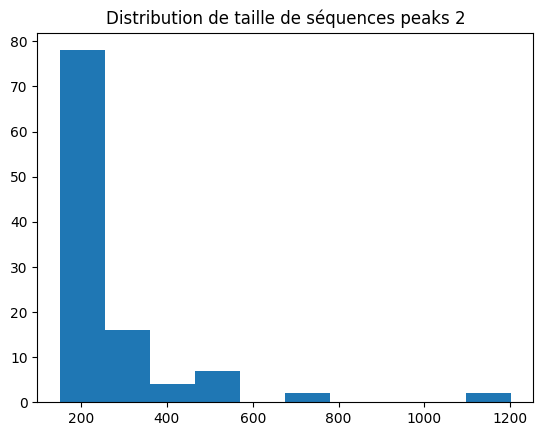

In [3]:
import matplotlib.pyplot as plt
tailles = [len(x) for x in peaks]

plt.hist(tailles)
plt.title("Distribution de taille de séquences peaks 2")

## Partie B : Regroupement de Motifs
Nous allons analyser les résultats des algorithmes de recherche de motifs.
Pour commencer, nous allons regrouper les motifs similaires à l'aide d'un algorithme de clustering hiérarchique.



1\. Pour regrouper les motifs nous allons contruire une liste avec, par exemple, les Top 20 motifs de l'algorithme HashTable (vous pouvez ensuite appliquer sur les résultats des autres algorithmes)

In [107]:
import motifsSearch as ms
import numpy as np
import suffix_trees as st

#Utiliser ce petit exemple pour tester votre code
motifs = ['ACG', 'ACC', 'ACT', 'CCA', 'CTA', 'CTC', 'CAC']

allkmers = ms.createKmers(5, 3, 3, 0.6, variation='yes')
motifs_ht = ms.hashTable(peaks, allkmers) #ms.medianStringSearch(peaks, allkmers) 
top_motifs = ms.getTopMotifs(motifs_ht, 20, decroissant = True)

motifs = [m for m in top_motifs]
print(motifs)

['CAGCA', 'ACAGC', 'TGCTG', 'AGCTG', 'CCAAG', 'TGCCA', 'TCAGC', 'CTGCT', 'ACCAG', 'TGCAG', 'ATGGC', 'GAAGC', 'GCTGA', 'GCTGT', 'GCTGC', 'CTGCA', 'CAGCT', 'CACAG', 'CTGTG', 'TGGCT']


2\. L'algorithme de regroupement a besoin des distances entre les séquences. Nous allons donc construire une matrice contenant toutes les distance entre tous les pairs de séquences et nous allons utiliser deux type de distance 'hamming' et 'levenshtein'.

In [90]:
def hamming(seq1, seq2):
  dist = 0
  for i in range(len(seq1)):
    if seq1[i] != seq2[i]:
      dist += 1
  return dist



In [91]:
#!pip install python-Levenshtein

In [92]:
import Levenshtein

def distance_matrix(motifs, typeDistance='ham'):
  # Calculate the distance matrix
  distance_matrix = np.zeros((len(motifs), len(motifs)))
  for i in range(len(motifs)):
    for j in range(len(motifs)):
      if i == j:
        distance_matrix[i][j] = 0
      if typeDistance == 'lev':
        distance_matrix[i][j] = Levenshtein.distance(motifs[i], motifs[j])
      elif typeDistance == 'ham':
        distance_matrix[i][j] = hamming(motifs[i], motifs[j])
  return distance_matrix

3\. Exécuter le code ci-dessous pour regrouper les motifs et visualiser les groupes. Tester avec les deux distances.


C:\Users\Kenjy\AppData\Local\Temp\ipykernel_1640\2269973410.py:7: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance, method='ward')


{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [45.0, 45.0, 55.0, 55.0],
  [30.0, 30.0, 50.0, 50.0],
  [10.0, 10.0, 40.0, 40.0],
  [65.0, 65.0, 75.0, 75.0],
  [95.0, 95.0, 105.0, 105.0],
  [85.0, 85.0, 100.0, 100.0],
  [70.0, 70.0, 92.5, 92.5],
  [115.0, 115.0, 125.0, 125.0],
  [135.0, 135.0, 145.0, 145.0],
  [120.0, 120.0, 140.0, 140.0],
  [155.0, 155.0, 165.0, 165.0],
  [185.0, 185.0, 195.0, 195.0],
  [175.0, 175.0, 190.0, 190.0],
  [160.0, 160.0, 182.5, 182.5],
  [130.0, 130.0, 171.25, 171.25],
  [81.25, 81.25, 150.625, 150.625],
  [25.0, 25.0, 115.9375, 115.9375]],
 'dcoord': [[0.0, np.float64(5.0), np.float64(5.0), 0.0],
  [0.0, np.float64(4.795831523312719), np.float64(4.795831523312719), 0.0],
  [0.0, np.float64(5.291502622129181), np.float64(5.291502622129181), 0.0],
  [np.float64(4.795831523312719),
   np.float64(6.363961030678928),
   np.float64(6.363961030678928),
   np.float64(5.291502622129181)],
  [np.float64(5.0),
   np.float64(8.051914886120775),
   n

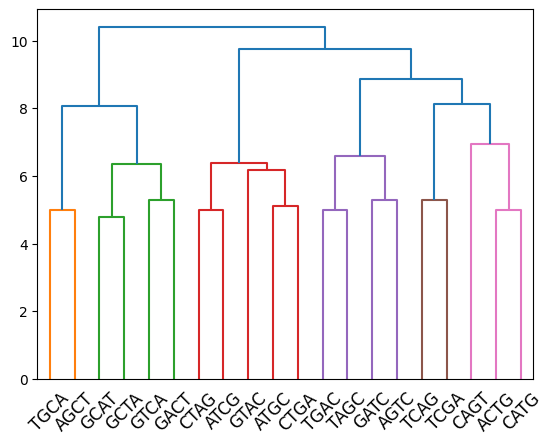

In [93]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Calculate the distance matrix
distance = distance_matrix(motifs, 'ham')

# Perform hierarchical clustering
linkage_matrix = linkage(distance, method='ward')

# Create a dendrogram
dendrogram(linkage_matrix, labels=motifs, leaf_rotation = 45)


### C -  Matrice de fréquences

1\. Séparer les motifs par groupes pour vérifier si les occurrences de chaque groupe est significatives. Pour cela, construire une matrice d'occurrence puis de probabilité pour représenter le motif.

In [101]:
nucs_pos = {
        "A":0,
        "T":1,
        "C":2,
        "G":3
    }
#Computing PWM
def pwm(motifs, k):
    nucs_pos = {
        "A":0,
        "T":1,
        "C":2,
        "G":3
    }

    #Matrice Occurences
    PWM = np.ones((4, k))
    for i in range(k):
        for m in motifs:
            nuc = m[i]
            ligne = nucs_pos[nuc]
            PWM[ligne][i] += 1

    #Matrice Fréquences
    s = len(motifs)+4
    PWM = PWM/s
    
    return PWM
k = len(motifs[0])
PWM = pwm(motifs, k)
print(PWM)

[[0.20833333 0.20833333 0.20833333 0.20833333 0.20833333]
 [0.25       0.20833333 0.16666667 0.16666667 0.20833333]
 [0.33333333 0.33333333 0.29166667 0.29166667 0.25      ]
 [0.20833333 0.25       0.33333333 0.33333333 0.33333333]]


2\. Déterminer les paramètres f(0)(b) du modèle nul, où
\begin{equation}
f^{(0)}(b) = \frac 1L \sum_{i=0}^{L-1} \omega_i(b)\ ,
\end{equation}

In [102]:
def f0_calcule(PWM, L):
    """
    Calcul les valeurs de probabilites d'un modele independant de positions (modele Null)
    entrée PWM : matrice de probabilites ou poids positions
    sortie  f_0 : vecteur contenant un modele independant de positions (modele Null)
    """
    f_0 = np.zeros(len(PWM[:,0]))
    for i in range(len(PWM[:,0])):
        p0 = 0
        for j in range(L):
            p0 += PWM[i][j]
        f_0[i] = p0/L

    return f_0

f_0 = f0_calcule(PWM, k)
print (f_0)

[0.20833333 0.2        0.3        0.29166667]


3\. Faites une fonction pour calculer log-rapport de vraisemblancee d'une sequence de taille k et la matrice poids position.
\begin{equation}
\ell(b_0,...,b_{k-1}) = \log_2 \frac {P(b_0,...,b_{k-1} | \omega )
}{P^{(0)}(b_0,...,b_{k-1})}
= \sum_{i=0}^{k-1} \log_2 \frac {\omega_i(b_i)}{f^{(0)}(b_i)}\ .
\end{equation}

In [103]:
def loglikehood(seq, PWM, f_0, k):
    """
    Calcul le rapport de vraissemblance entre une sequence et une matrice de poids position
    entrée PWM : matrice de probabilites ou poids positions
    entrée f_0 : vecteur contenant le modele independant de positions (modele Null)
    entrée seq : une sequence d'ADN de taille k, ou k est le nombre de colonnes de PWM
    sortie ll : rapport de vraissemblance
    """
    nucs = ("A", "T", "C", "G")

    ll = 0.0

    p0_seq = 1
    p_seq = 1
    for i in range(k):
        p0_seq *= f_0[nucs.index(seq[i])]
        p_seq *= PWM[nucs.index(seq[i])][i]

    ll = np.log2(p_seq/p0_seq)
    return ll
    
    nucs_pos = {
        "A":0,
        "T":1,
        "C":2,
        "G":3
    }
    L = len(seq)
    likelyhoods = np.array([])
    for i in range(L-k+1):
        motif = seq[i:i+k]
        p0_nuc = 1
        p_nuc = 1
        for j in range(len(motif)):
            nuc = motif[j]
            p0_nuc *= f_0[nucs_pos[nuc]]
            p_nuc *= PWM[nucs_pos[nuc],j]
        l = np.log2(p_nuc/p0_nuc)
        likelyhoods = np.append(likelyhoods,l)
        
    ll = np.mean(likelyhoods)

    #print(likelyhoods)
    return ll

#loglikehood('acctgcaccc'.upper(), PWM, f_0, k)
loglikehood('GGTGAG',PWM , f_0, k)

np.float64(-0.7782085763980873)

4\. Faire une fonction que pour chaque séquence cherche la/les positions avec une log-vraisemblance positive.

In [106]:
def searchPWM(sequences, k, PWM, f_0):
    """
    Cherche les positions dans un ensemble de séquence qui maxime le rapport de vraisemblance
    entrée sequences : ensemble de séquence d'ADN
    entrée k : nombre de colonnes d'PWM
    entrée PWM : matrice de probabilités ou poids positions
    entrée f_0 : vecteur contenant le modèle indépendant de positions (modèle Null)
    sortie posList: liste contenant pour chaque séquence la/les positions ayant un rapport de vraisemblance positive
    """
    count = 0; posList = []
    motifsT = []
    for seq in sequences:
        best = (None, 0, None)
        for i in range(0,len(seq)-k+1):
            llkmer = loglikehood(seq[i:i+k], PWM, f_0, k)
            if llkmer > best[1]:
                best = (i, float(llkmer), seq[i:i+k]) #(seq[i:i+k],llkmer)

        if best[0] != None:
            posList.append((best[0], best[1], best[2]))

    return posList

posList = searchPWM(peaks, k, PWM, f_0)
print(posList)

[(282, 0.8250056288792912, 'TTGGT'), (98, 0.7661119398257229, 'TTAGG'), (46, 0.8592213442172045, 'TCAGG'), (259, 0.7661119398257229, 'TTAGG'), (88, 0.8250056288792912, 'TTGGT'), (188, 0.7661119398257228, 'TTGGA'), (14, 0.7661119398257229, 'TTAGG'), (0, 0.8250056288792912, 'TTGGT'), (13, 0.7254699553283768, 'TCAGT'), (34, 0.8250056288792912, 'TTGGT'), (363, 1.0518664221596004, 'TCGGG'), (23, 0.8819414207172881, 'CCGGG'), (66, 0.7661119398257229, 'TTGAG'), (16, 0.8250056288792912, 'TTGGT'), (112, 0.729938327272238, 'ACGGG'), (26, 0.7072182507721542, 'TAAGG'), (57, 0.8998633287145501, 'TAGGG'), (93, 0.725469955328377, 'TTGCG'), (294, 0.8819414207172881, 'CCGGG'), (321, 0.9587570177681187, 'TTGGG'), (440, 0.8819414207172881, 'CCGGG'), (138, 0.7072182507721542, 'TAGGA'), (215, 0.9181150332707727, 'TCGGT'), (174, 0.9587570177681187, 'TTGGG'), (32, 0.7888320163258062, 'CTGGG'), (121, 0.9181150332707727, 'TCGGT'), (64, 0.7661119398257228, 'TTGGA'), (23, 0.8592213442172045, 'TCGAG'), (246, 0.95

5\. Conter combien de séquences dans votre fichier ont une loglikellyhood positive et calculer la proposition par rapport au total de séquences de votre fichier

In [105]:
print(len(posList)/len(peaks)*100, "%")
print(peaks[0][166:172])

100.0 %
ACCAGT
